**In this notebook, we have distilbert model. We added classification head on the top of it. And in training process, we freezed the inner layers weight and biases and only changable parameters are in the classification head.**

In [ ]:
!pip install keras-core --upgrade
!pip install -q keras-nlp
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 22.3 MB/s eta 0:00:0000:01
  Attempting uninstall: keras-core
    Found existing installation: keras-core 0.1.5
    Uninstalling keras-core-0.1.5:
      Successfully uninstalled keras-core-0.1.5


In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_core as keras
import keras_nlp
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import json
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("KerasNLP version:", keras_nlp.__version__)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Using TensorFlow backend
TensorFlow version: 2.12.0
Keras version: 0.1.7
KerasNLP version: 0.6.1


# Load The Data

In [ ]:
data_dir='/kaggle/input/sarcasm-detection-dataset/sarcasm-detection-dataset.csv'

In [ ]:
data = pd.read_csv(data_dir)

**We will convert our data to a data frame**

In [ ]:
df = pd.DataFrame(data)

**Let's see our data**

In [ ]:
df = df[['text', 'label']]
df.head()

,text,label
0,In Pictures: 8 asanas brought to you by PM Mod...,1
1,Diesel costlier by 3 as Bihar government withd...,0
2,NASA Releases Satellite Image Of Apology Lette...,1
3,Global real estate to get uniform internationa...,0
4,"Kanye West New Girlfriend, Chaney Jones Leaves...",1


# Exploratory Data Analysis

In [ ]:
df.isna().sum()

text     0
label    0
dtype: int64

In [ ]:
df.duplicated().sum()

5

In [ ]:
df.drop_duplicates(inplace=True)

# Create the model

**we're using Destilbert transformer**


**DistilBERT is a compact version of the powerful BERT (Bidirectional Encoder Representations from Transformers) language model.**

In [ ]:
# We choose 512 because it's the limit of DistilBert
SEQ_LENGTH = 512

# Use a shorter sequence length.
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=SEQ_LENGTH,
)

# Pretrained classifier.
classifier = keras_nlp.models.DistilBertClassifier.from_preset(
    "distil_bert_base_en_uncased",
    num_classes=2,
    activation=None,
    preprocessor=preprocessor,
)

# Re-compile (e.g., with a new learning rate)
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(1e-4),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy()
   ]
)


# Access backbone programmatically (e.g., to change `trainable`).
classifier.backbone.trainable = False


classifier.summary()

231508/231508 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step       
265570304/265570304 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Preprocessor: "distil_bert_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Tokenizer (type)                                   ┃                                             Vocab # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)        │                                              30,522 │
└────────────────────────────────────────────────────┴─────────────────────────────────────────────────────┘

Model: "distil_bert_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃     Param # ┃ Connected to                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │           0 │ -                              │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │           0 │ -                              │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │  66,362,880 │ padding_mask[0][0],            │
│ (DistilBertBackbone)          │                           │             │ token_ids[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │           0 │ distil_bert_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │     590,592 │ get_item[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │           0 │ pooled_dense[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │       1,538 │ classifier_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────┴────────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 592,130 (2.26 MB)

 Non-trainable params: 66,362,880 (253.15 MB)

# Splitting The Data

In [ ]:
# Split the dataset into train and test sets
X_temp, X_test, y_temp, y_test = train_test_split(df["text"],
                                                    df["label"],
                                                    test_size=0.30,
                                                    random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp,
                                                  y_temp,
                                                  test_size=0.20,
                                                  random_state=42)


In [ ]:
# Fit
classifier.fit(x=X_train,
               y=y_train,
               validation_data=(X_test, y_test),
               epochs=12,
               batch_size=64
              )

Epoch 1/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - loss: 0.6429 - sparse_categorical_accuracy: 0.6788 - val_loss: 0.4809 - val_sparse_categorical_accuracy: 0.8035
Epoch 2/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 53s 750ms/step - loss: 0.4694 - sparse_categorical_accuracy: 0.8016 - val_loss: 0.4041 - val_sparse_categorical_accuracy: 0.8237
Epoch 3/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 53s 751ms/step - loss: 0.4043 - sparse_categorical_accuracy: 0.8284 - val_loss: 0.3771 - val_sparse_categorical_accuracy: 0.8360
Epoch 4/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 53s 751ms/step - loss: 0.3732 - sparse_categorical_accuracy: 0.8393 - val_loss: 0.3640 - val_sparse_categorical_accuracy: 0.8455
Epoch 5/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 53s 751ms/step - loss: 0.3717 - sparse_categorical_accuracy: 0.8433 - val_loss: 0.3549 - val_sparse_categorical_accuracy: 0.8504
Epoch 6/12
71/71 ━━━━━━━━━━━━━━━━━━━━ 57s 806ms/step - loss: 0.3561 - sparse_categorical_accuracy: 0.8524 - val_loss: 0.3459 - val_sparse_categorical_accuracy: 0.8537


# Evaluating The Model

In [ ]:
def displayConfusionMatrix(y_true, y_pred, dataset):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred, axis=1),
        display_labels=["Not_Sarcastic",'Is_Sarcastic'],
        cmap=plt.cm.Blues
    )
    F1_Score = f1_score(y_true, np.argmax(y_pred, axis=1))
    disp.ax_.set_title("Confusion Matrix on " + dataset + " Dataset -- F1 Score: " + str(F1_Score.round(2)))

In [ ]:
y_pred_val = classifier.predict(X_val)

36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 369ms/step


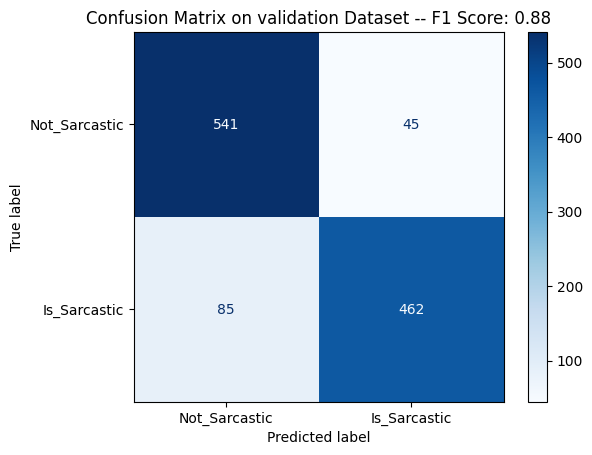

In [ ]:
displayConfusionMatrix(y_val, y_pred_val,  "validation")

In [ ]:
y_pred_test = classifier.predict(X_test)

76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 306ms/step


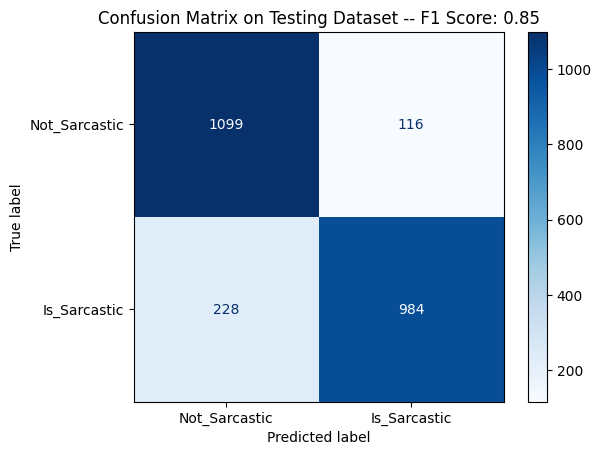

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
displayConfusionMatrix(y_test, y_pred_test,  "Testing")

In [ ]:
y_pred_test_new = []
for tt in list(y_pred_test):
    if tt[0] > tt[1]:
        y_pred_test_new.append(0)
    else:
        y_pred_test_new.append(1)

result = pd.DataFrame({
    'X_test': list(X_test),
    'y_test': list(y_test),
    'y_pred_test': list(y_pred_test_new)
})

In [ ]:
result

,X_test,y_test,y_pred_test
0,Dog dies of rabies; activists for vaccination ...,0,0
1,Catholic association calls for security for fe...,0,0
2,BJP government encouraging lynchings in Rajast...,0,0
3,"UnReal Primer: EPF rules, highway robbery and ...",1,0
4,Survey: More Than 1000 Doppelgängers Of Zayn M...,1,0
...,...,...,...
2422,CRACKED! Dutt-Sardesai algorithm behind “Lette...,1,1
2423,New generation fights to inherit political leg...,0,0
2424,Maharashtra govt. to run special buses for Aar...,1,0
2425,UP Election: Congress Condemns Yogi Adityanath...,1,0


In [ ]:
wrong_results = result[result['y_test'] != result['y_pred_test']]

In [ ]:
wrong_results.to_csv('wrong_result.csv')
wrong_results


,X_test,y_test,y_pred_test
3,"UnReal Primer: EPF rules, highway robbery and ...",1,0
4,Survey: More Than 1000 Doppelgängers Of Zayn M...,1,0
5,Janhvi Kapoor caught using mobile in auto; say...,1,0
6,Backing Pachauri is like saying women's safety...,0,1
8,How demonetisation has affected tipping,1,0
...,...,...,...
2400,Delhi Metro to lower its AC temperature to avo...,1,0
2411,Citizens rush out of homes in Ahmedabad after ...,0,1
2416,Rejected petition can't be taken to Supreme Co...,0,1
2424,Maharashtra govt. to run special buses for Aar...,1,0


In [ ]:
# from the wrong results we can try to infer why our model is giving wrong results

# one of the reason is the lack of context.
# for example

# "West Indian Cricket Board approaches Mel McLaughlin to coach team"
# this text seems normal, but its actually sarcastic because Mel McLaughlin is news respresentor

# more such type of cases can be found.